## **OpenCV Feature Detection & Object Detection Assignment**

This notebook presents the implementation of various computer vision techniques using OpenCV, such as corner detection, feature extraction, image segmentation, and object detection.

### **Import all necessary libraries in one place for use across all tasks**

In [1]:
# Import the necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


### **Q1: Harris Corner Detection**

The Harris Corner Detection algorithm detects corners in an image by examining variations in pixel intensity. It is commonly applied in tasks like image matching and object tracking.

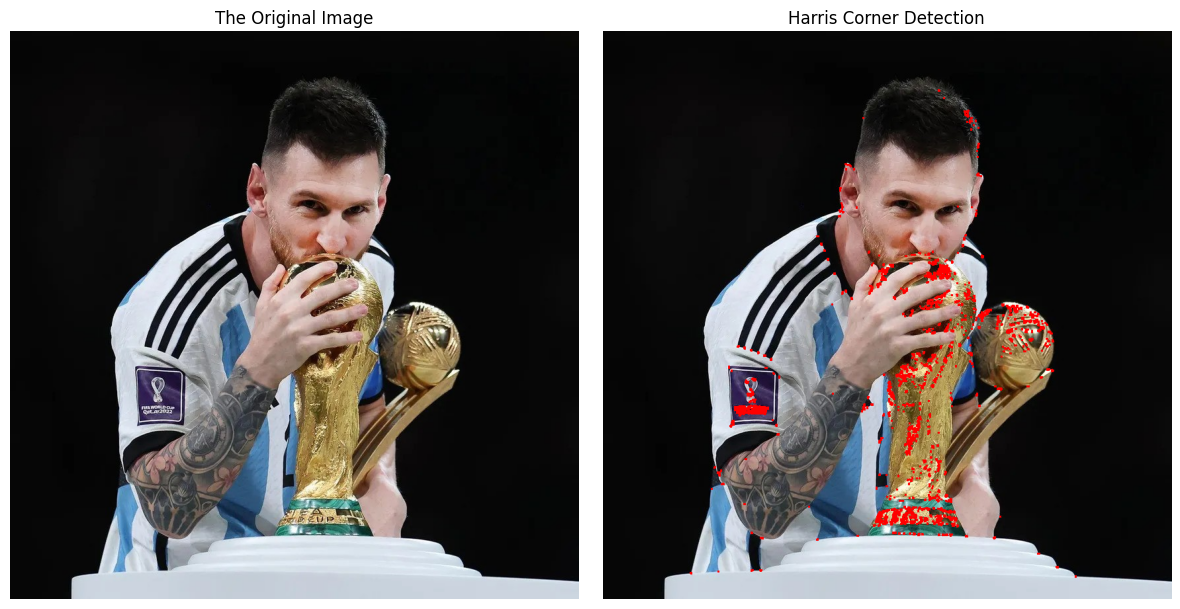

In [ ]:
def apply_harris_corner_detection(image_path, block_size=2, ksize=3, k=0.04, threshold=0.01):
    """
    Apply Harris Corner Detection on an image and return both original and result images.

    Parameters:
    - image_path (str): Path to the input image
    - block_size (int): Neighborhood size
    - ksize (int): Aperture parameter for the Sobel operator
    - k (float): Harris detector free parameter
    - threshold (float): Threshold for detecting strong corners

    Returns:
    - original_img (ndarray): Original input image
    - result_img (ndarray): Image with corners marked
    """
    image = cv2.imread(image_path)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    grayscale = np.float32(grayscale)

    harris_response = cv2.cornerHarris(grayscale, blockSize=block_size, ksize=ksize, k=k)
    harris_response = cv2.dilate(harris_response, None)

    corner_mask = harris_response > threshold * harris_response.max()
    result_img = image.copy()
    result_img[corner_mask] = [0, 0, 255]  # Red color for corners

    return image, result_img

# Original image
img_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\MESSI.jpg' 
original, harris_result = apply_harris_corner_detection(img_path)

# Plot side-by-side
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("The Original Image")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Harris Corner Detection")
plt.imshow(cv2.cvtColor(harris_result, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

#### **Visualization Output:**

**Harris Corner Detection Output**

- On the left side, we have the original image of Messi holding the World Cup trophy. This is just the plain image with no changes.

- On the right side, we see the same image after applying Harris Corner Detection. All those red dots that we see on Messi’s face, hand, trophy, and even his shirt represent the corners detected by the algorithm.

### **Interpretation:**

- The algorithm successfully identified distinctive corner points across the image. These red dots represent important features that stand out due to sharp changes in intensity. It also can be used for other computer vision tasks like tracking objects, matching images, or even recognizing specific parts of the image.

### **Q2: Image Pyramid**

Image pyramids are a technique used to display the same image at different scales or resolutions. This approach is helpful for detecting objects of various sizes in an image.|

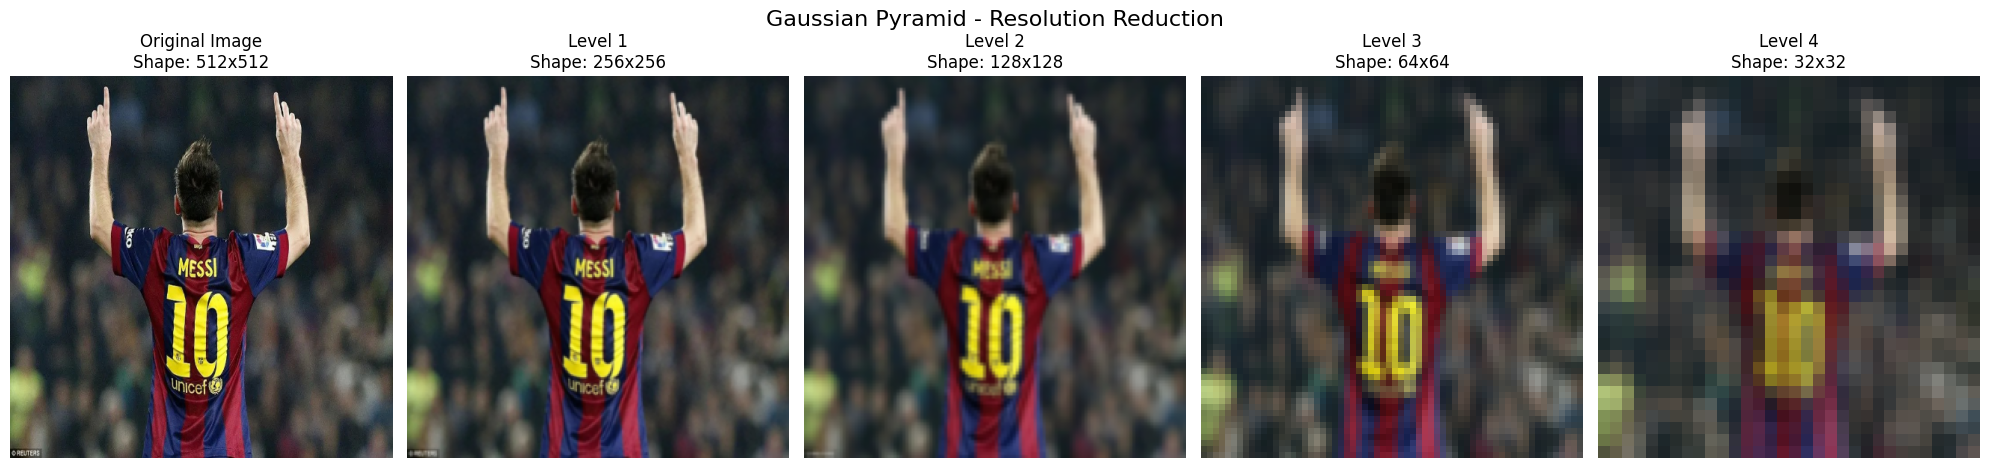

In [ ]:
def display_image_pyramid_with_shape(image_path, levels=5):
    """
    Construct and display a Gaussian image pyramid with level and resolution info.

    Parameters:
    - image_path (str): Path to the original image
    - levels (int): Number of pyramid levels (including original)
    """
    image = cv2.imread(image_path)
    image = cv2.resize(image, (512, 512))  # Resize to make pyramid levels consistent
    current_img = image.copy()
    
    pyramid = [current_img]

    # Create Gaussian pyramid
    for _ in range(1, levels):
        current_img = cv2.pyrDown(current_img)
        pyramid.append(current_img)

    # Display all levels with shape
    plt.figure(figsize=(20, 5))
    for idx, img in enumerate(pyramid):
        shape = f"{img.shape[0]}x{img.shape[1]}"
        title = "Original Image" if idx == 0 else f"Level {idx}"
        title += f"\nShape: {shape}"
        plt.subplot(1, levels, idx + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')

    plt.suptitle('Gaussian Pyramid - Resolution Reduction', fontsize=16)
    plt.tight_layout()
    plt.show()

# Upload image/original image
img_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\UCL.jpg'
display_image_pyramid_with_shape(img_path)


#### **Visualization Output:**

- **Original Image**: 512x512 pixels
- **Level 1**: 256×256 pixels  
- **Level 2**: 128x128 pixels  
- **Level 3**: 64x64 pixels  
- **Level 4**: 32x32 pixels 

- The first image on the left is the original image, and each image to the right is a progressively smaller version of it.

- Each level is labeled with both its level number and the image resolution (height × width).

- As the levels go up, the image becomes more blurred and pixelated, because the resolution gets lower each time I apply the pyrDown() function.

#### **Interpretation:**

- The higher levels (like Level 3 or Level 4) still preserve the basic shape and structure of the subject, even though the details are gone.

- This makes it helpful in tasks like image blending, object detection at various scales, and image compression.

Overall, the pyramid gives a powerful way to view and process images from coarse to fine detail.

### **Q3: Image Segmentation using Watershed Algorithm**

The watershed algorithm views grayscale images as topographic surfaces and is commonly used to separate or segment objects that overlap within an image.

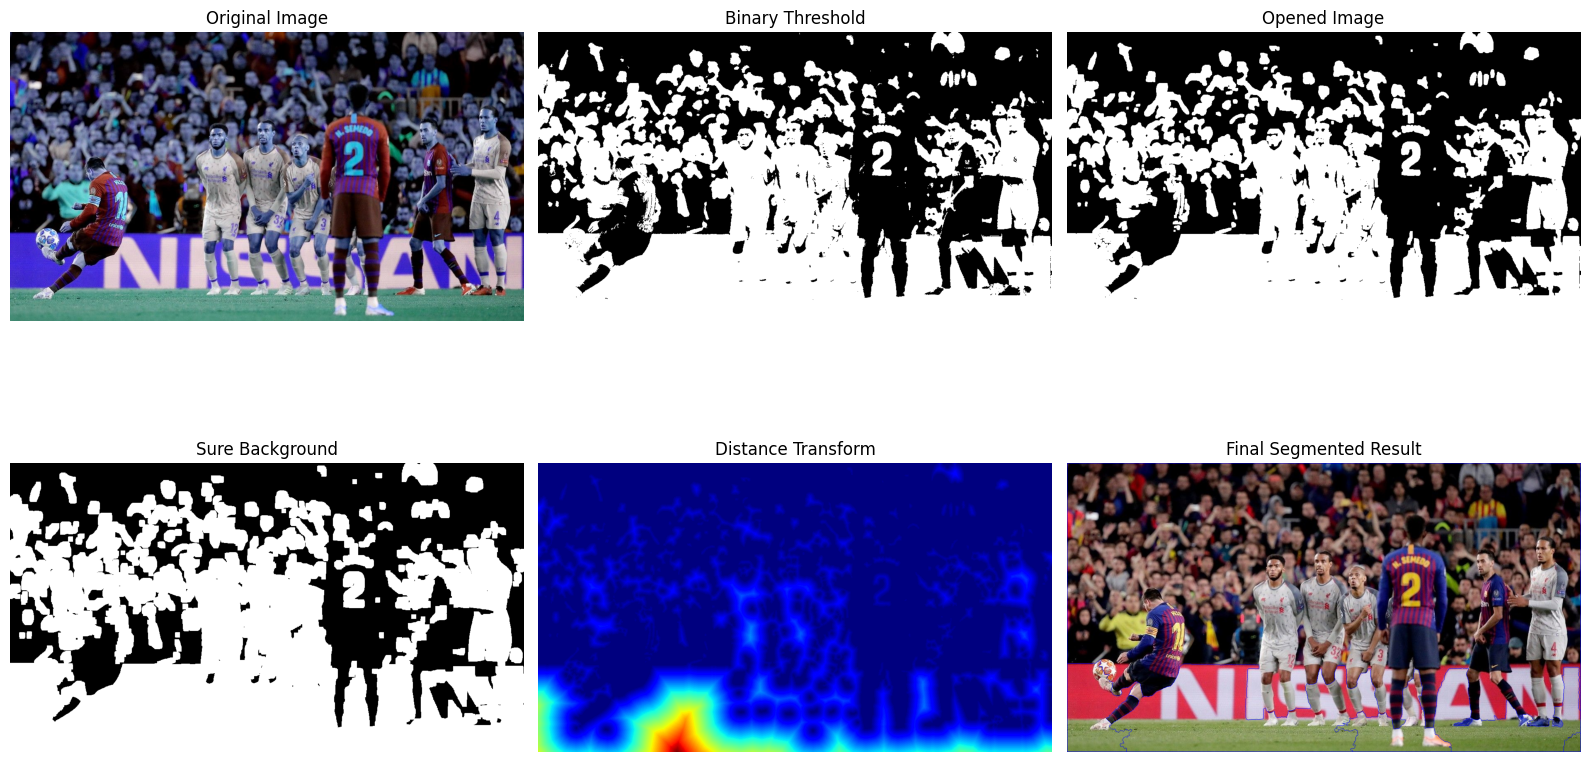

In [ ]:
def segment_using_watershed(image_path):
    """
    Perform image segmentation using the Watershed algorithm.

    Parameters:
    - image_path (str): Path to the image for segmentation

    Returns:
    - segmented_img (ndarray): Image with segmentation borders
    """
    img = cv2.imread(image_path)
    original = img.copy()

    # Apply mean shift filtering
    filtered = cv2.pyrMeanShiftFiltering(img, sp=21, sr=51)
    gray = cv2.cvtColor(filtered, cv2.COLOR_BGR2GRAY)

    # Binarize using Otsu's method
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological operations to clean up the mask
    kernel = np.ones((3, 3), np.uint8)
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    # Background area
    sure_bg = cv2.dilate(opened, kernel, iterations=3)

    # Foreground area using distance transform
    dist_map = cv2.distanceTransform(opened, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_map, 0.4 * dist_map.max(), 255, 0)

    # Find unknown region
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Marker labeling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply Watershed
    cv2.watershed(img, markers)
    img[markers == -1] = [255, 0, 0]  # Mark boundary in red

    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    titles = [
        "Original Image", "Binary Threshold", "Opened Image",
        "Sure Background", "Distance Transform", "Final Segmented Result"
    ]
    images = [
        original, binary, opened,
        sure_bg, dist_map, img
    ]
    cmaps = ['gray', 'gray', 'gray', 'gray', 'jet', None]

    for idx, ax in enumerate(axes.flat):
        if cmaps[idx]:
            ax.imshow(images[idx], cmap=cmaps[idx])
        else:
            ax.imshow(cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(titles[idx])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Loading image/original image
segment_using_watershed(r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\FREE_KICK.jpg')

### **Visualization Output**

| **Steps**                | **Description**                                                                 |
|-------------------------|---------------------------------------------------------------------------------|
| Original Image          | The starting image shows players lined up for the kick.                        |
| Binary Threshold        | Converted to black and white using Otsu’s method to separate foreground from background. |
| Opened Image            | Cleaned up small noise and gaps using morphological operations.                |
| Sure Background         | Identified solid background areas by dilation.                                 |
| Distance Transform      | Highlighted how far each pixel is from the background to help find object centers. |
| Final Segmented Result  | Red boundary lines appear around the players, showing where segmentation happened. |


### **Interpretation**

The Watershed algorithm helped to separate overlapping players, especially those in the wall. With preprocessing, it was able to detect clear boundaries and mark them in red. This technique works well in sports scenarios where players are close together, and accurate separation is needed for analysis or tracking.

### **Q4: SIFT Feature Detection**

SIFT (Scale-Invariant Feature Transform) is a technique used to identify and describe key local features within an image, regardless of scale or rotation.

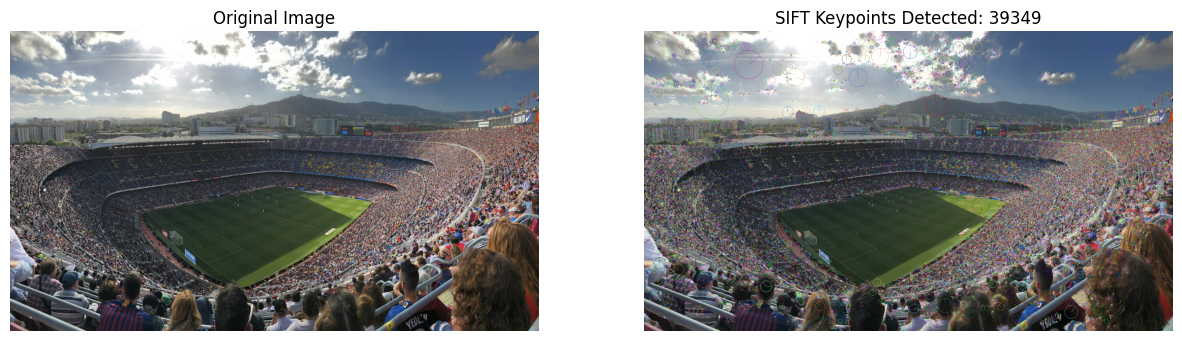

In [ ]:
def detect_sift_features(image_path):
    """
    Detect and visualize SIFT keypoints in an image.

    Parameters:
    - image_path (str): Path to the input image

    Returns:
    - original_img (ndarray): Original loaded image
    - keypoint_img (ndarray): Image with SIFT keypoints drawn
    - num_keypoints (int): Number of keypoints detected
    """
    original_img = cv2.imread(image_path)
    grayscale = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    # Create SIFT detector instance
    sift = cv2.SIFT_create()

    # Detect keypoints and compute descriptors
    keypoints, descriptors = sift.detectAndCompute(grayscale, None)

    # Draw keypoints on the image
    keypoint_img = cv2.drawKeypoints(
        original_img, keypoints, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    return original_img, keypoint_img, len(keypoints)

# Loading image/original image
img_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\CAMPNOU.jpg'
original_img, sift_img, num_kps = detect_sift_features(img_path)

# Display original and SIFT-detected images side by side
plt.figure(figsize=(15, 6))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# SIFT image
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sift_img, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints Detected: {num_kps}")
plt.axis('off')

plt.show()

### **Visualization Output**

- On the left side, the original image is displayed without any changes i.e. just the full stadium scene.

- On the right side, we can see the SIFT keypoints overlaid on the image as circles of different sizes and orientations. Each circle represents a keypoint detected by the algorithm.

The title shows that 39,349 keypoints were detected, which means the image has a lot of local features and texture.

### **Interpretation**

This result shows that the SIFT algorithm is highly effective for feature detection in complex scenes. Since the stadium is full of people, seats, and architectural details, there are thousands of points where the image changes significantly and SIFT picks up all of these as keypoints as mentionde below:

- These keypoints can be used for tasks like object matching, tracking, or stitching images together.

- Even with variations in scale or angle, SIFT is able to detect reliable and repeatable features.

- It’s especially useful in sports scenes like this, where there's a lot of detail, motion, and variation in textures.

### **Q5: Object Detection using YOLO on COCO Dataset**

YOLO (You Only Look Once) is a fast and efficient object detection model that identifies and classifies multiple objects in real-time. It is trained on the COCO dataset, which contains a wide variety of everyday object categories.

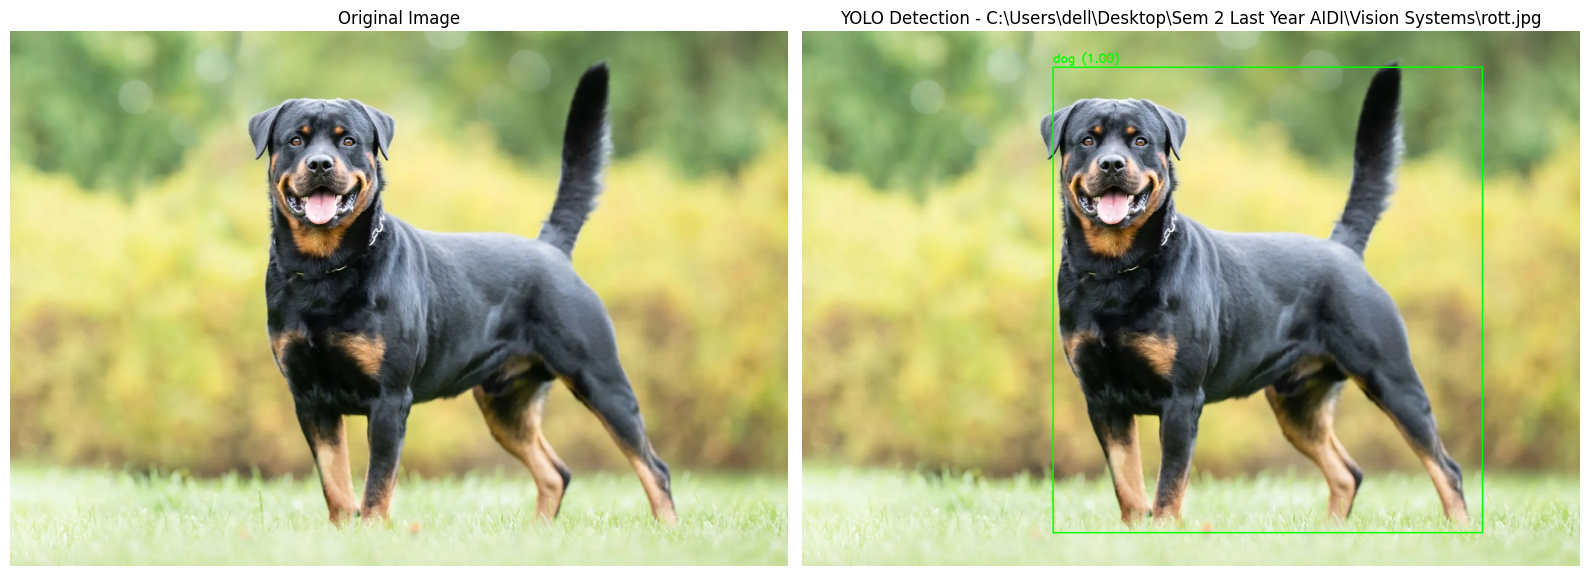

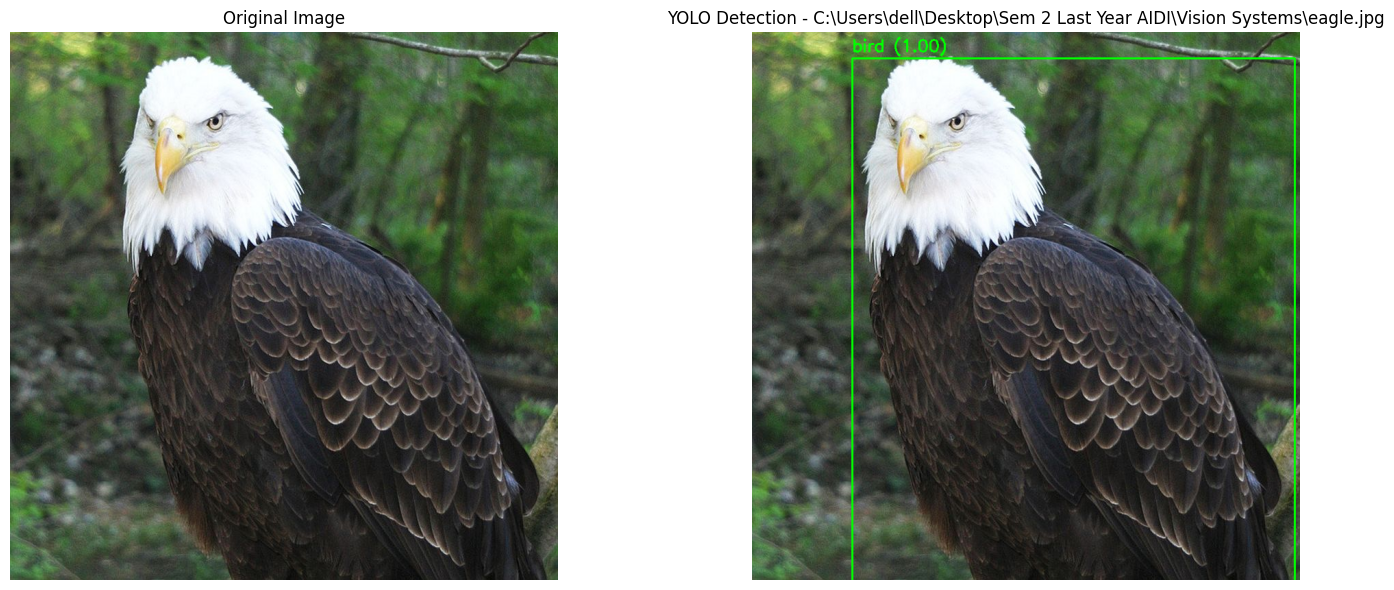

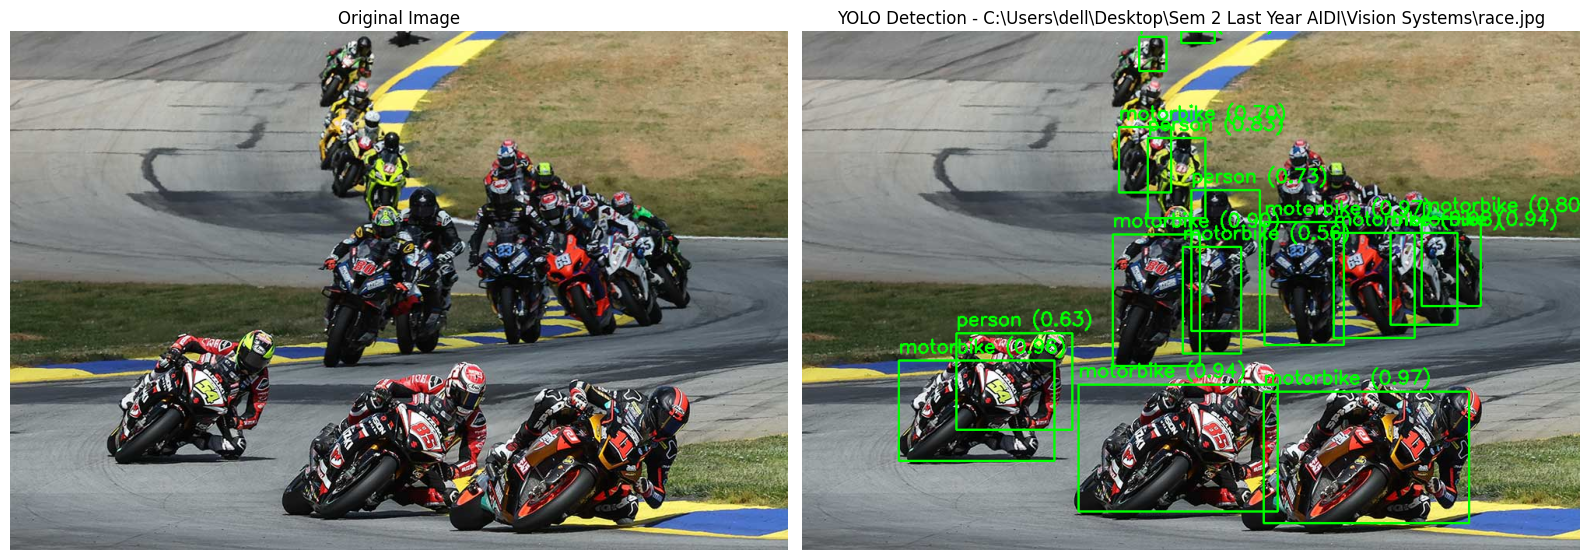

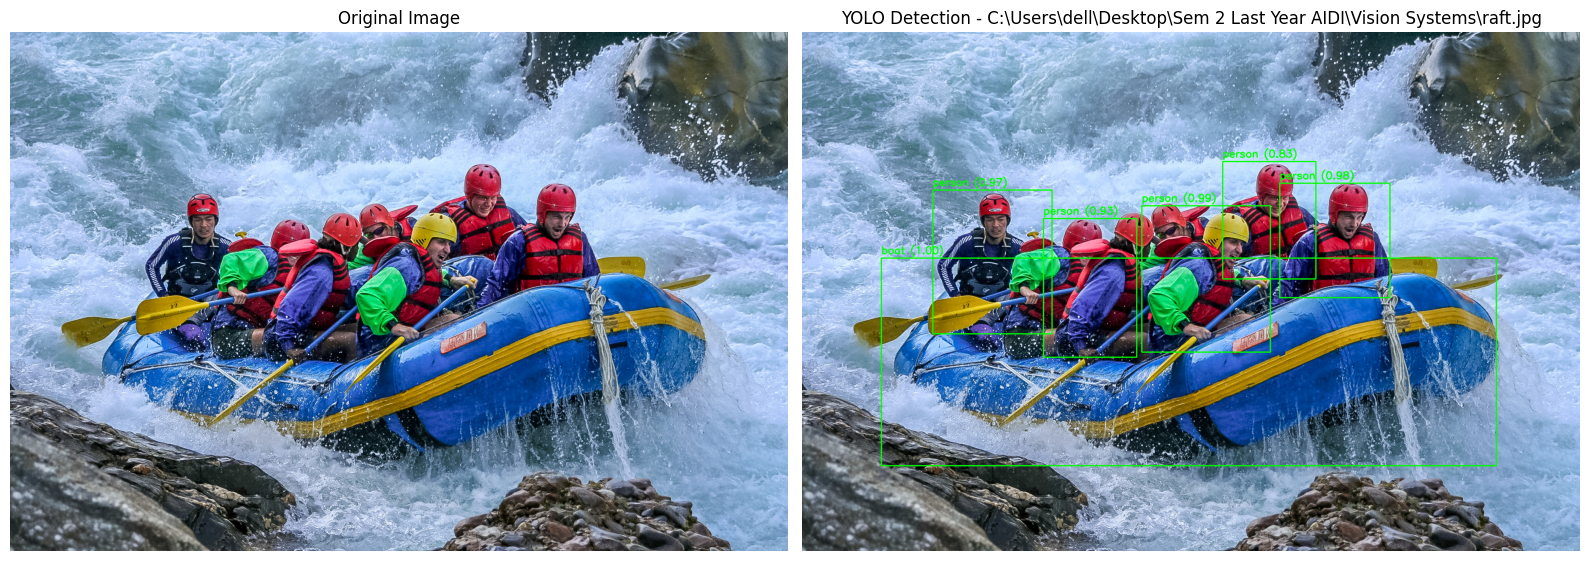

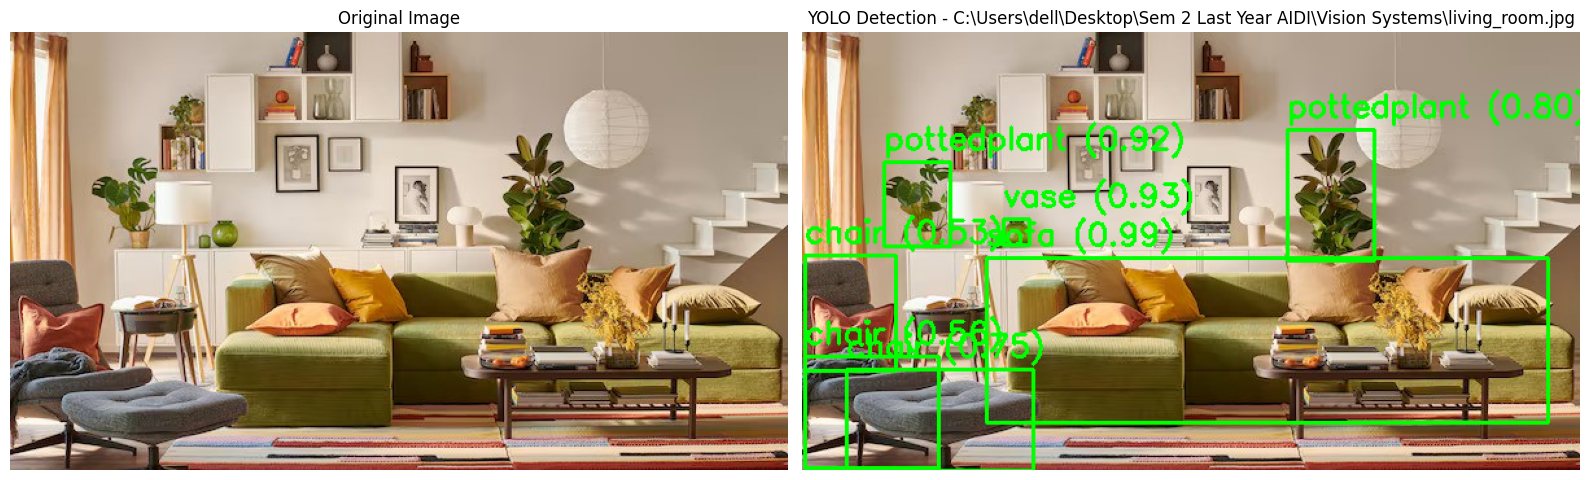

In [8]:
def load_yolo(cfg_path, weights_path, names_path):
    """
    Load YOLO model and output layers.

    Parameters:
        cfg_path (str): Path to YOLO configuration file.
        weights_path (str): Path to pre-trained weights file.
        names_path (str): Path to file containing class labels.

    Returns:
        net (cv2.dnn.Net): Loaded YOLO model.
        output_layers (list): Output layer names used for detection.
        class_labels (list): List of class names.
    """
    net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

    with open(names_path, "r") as f:
        class_labels = [line.strip() for line in f.readlines()]
    
    return net, output_layers, class_labels


def detect_objects(image_path, net, output_layers, class_labels, confidence_threshold=0.5, nms_threshold=0.4):
    """
    Perform object detection on a single image using YOLOv3.

    Parameters:
        image_path (str): Path to input image.
        net (cv2.dnn.Net): Loaded YOLO model.
        output_layers (list): List of output layer names.
        class_labels (list): List of class names.
        confidence_threshold (float): Minimum confidence to filter weak detections.
        nms_threshold (float): Threshold for Non-Maximum Suppression.

    Returns:
        original (ndarray): Original image.
        annotated (ndarray): Image with detection boxes and labels drawn.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"[ERROR] Failed to load image: {image_path}")
        return None, None

    original = image.copy()
    height, width = image.shape[:2]

    # Create a blob from the image and perform a forward pass
    blob = cv2.dnn.blobFromImage(image, 1 / 255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)
    detections = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    for output in detections:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            score = scores[class_id]

            if score > confidence_threshold:
                center_x, center_y, w, h = (detection[:4] * [width, height, width, height]).astype('int')
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, int(w), int(h)])
                confidences.append(float(score))
                class_ids.append(class_id)

    indices = cv2.dnn.NMSBoxes(boxes, confidences, confidence_threshold, nms_threshold)

    if len(indices) > 0:
        for i in np.array(indices).flatten():
            x, y, w, h = boxes[i]
            label = f"{class_labels[class_ids[i]]} ({confidences[i]:.2f})"
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    return original, image


# File paths for YOLO configuration
cfg_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\yolov3.cfg'
weights_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\yolov3.weights'
names_path = names_path = r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\coco.names'

# Load model
yolo_net, yolo_outputs, yolo_classes = load_yolo(cfg_path, weights_path, names_path)

# List of images
image_files = [
    r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\rott.jpg',
    r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\eagle.jpg',
    r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\race.jpg',
    r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\raft.jpg',
    r'C:\Users\dell\Desktop\Sem 2 Last Year AIDI\Vision Systems\living_room.jpg'
]

# Visualize results
for img_path in image_files:
    original_img, detected_img = detect_objects(img_path, yolo_net, yolo_outputs, yolo_classes)

    if detected_img is None:
        continue

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
    ax[1].set_title(f"YOLO Detection - {img_path}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


### **Visualization Output**

| **Images**           | **Detected Objects**     | **Highest Confidence** | **Key Insights**                                           |
|---------------------|--------------------------|-------------------------|------------------------------------------------------------|
| Dog                 | dog                      | 1.00                    | Clear single-object detection                             |
| Bird/Eagle               | bird                     | 1.00                    | Good generalization on animal class                       |
| Motorbike Race      | motorbike, person        | 0.50–0.97               | Performs well in fast-action multi-object environments    |
| Raft                | people, boat             | 0.83–1.00               | Reliable for multi-object detection in motion             |
| Living Room         | couch, vase, plant       | 0.93–0.96               | Accurate for indoor object detection                      |

### **Interpretation**

YYOLOv3 proves to be a reliable real-time object detection system. It effectively handles:

- Single-object detection in clean settings,

- Multi-object recognition in both still and fast-paced environments, and object classification in cluttered indoor scenes.

These results validate YOLOv3’s versatility and robustness across a wide range of real-world scenarios.


### **Thank You**